In [1]:
import pandas as pd
import os
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shutil
import muon as mu
import scirpy as ir
import anndata
from tqdm import tqdm
from scipy.stats import entropy
import matplotlib.patches as mpatches

import rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

from rpy2.robjects.conversion import localconverter

%load_ext rpy2.ipython

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packag

In [2]:
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata_new_correct_progression.h5ad')

In [3]:
adata = adata[adata.obs['annot_final'].isin([
     'CD8 Tem Cell',
     'Tactiv Cell',
     'GZMK+ CD8 T progenitor ex Cell',
     'Th17/Tc17',
     'Tc17',
     'CD8 Cytotoxic T Cell',
     'CD8 HSP T cell',
     'Tprolif Cell',
     'T naive/early memory Cell',
     'Terminal CD8 Tex Cell',
])]

In [4]:
adata.obs['clonotype_patient'] = adata.obs['clonotype'].astype(str) + '_' + adata.obs['patient'].astype(str)

/tmp/ipykernel_2653/3600024150.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['clonotype_patient'] = adata.obs['clonotype'].astype(str) + '_' + adata.obs['patient'].astype(str)


In [5]:
color_dict = {
    'T naive/early memory Cell' : '#1f77b4',
    'GZMK+ CD8 T progrenitor ex Cell' : '#aec7e8',
    'CD8 Tem Cell' : '#ff7f0e',
    'Tactiv Cell' : '#ffbb78',
    'CD8 HSP T cell' : '#98df8a',
    'CD8 T naive/early memory Cell' : '#d62728',
    'CD4 T naive/early memory Cell' : '#ff9896',
    'CD8 Cytotoxic T Cell' : '#9467bd',
    'Tprolif Cell' : '#8c564b',
    'Treg' : '#c49c94',
    'Tc17' : '#e377c2',
    'Terminal CD8 Tex Cell' : '#f7b6d2',
    'Th17/Tc17' : '#c7c7c7',
    'gd T Cell' : '#bcbd22',
    'NKT' : '#dbdb8d',
    'Th17' : '#17becf',
    'Tnaive Cell' : '#9edae5'
}

In [6]:
patient_progression = adata.obs[['patient','progression']].drop_duplicates()
patient_progression.index = patient_progression['patient']
patient_progression = patient_progression['progression'].to_dict()

# F1

In [7]:
clonotypes_f1 = adata[adata.obs['timepoint'] == 'F1'].obs['clonotype_patient'].unique().tolist()
clonotypes_b = adata[adata.obs['timepoint'] == 'B'].obs['clonotype_patient'].unique().tolist()

In [8]:
new_f1_clonotypes = [i for i in clonotypes_f1 if i not in clonotypes_b]

In [9]:
clonotype_counts_f1 = pd.DataFrame(adata[(adata.obs['timepoint'] == 'F1') & (
    adata.obs['clonotype_patient'].isin(new_f1_clonotypes)
)].obs['clonotype_patient'].value_counts())

In [10]:
sample_counts = pd.read_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/cell_counts_by_sample.csv')

In [11]:
sample_counts.index = sample_counts['Sample']
sample_counts

,Sample,Timepoint_Progression,Total,Immune,T cells
Sample,,,,,
E12_B,E12_B,B_Slow,833,644,358
E12_F1,E12_F1,F1_Slow,4651,3929,2906
E12_F2,E12_F2,F2_Slow,4240,3355,2253
E14_B,E14_B,B_Fast,1003,609,322
E14_F1,E14_F1,F1_Fast,1073,521,310
...,...,...,...,...,...
E45_F1,E45_F1,F1_Slow,2391,2032,737
E45_F2,E45_F2,F2_Slow,578,536,83
E46_B,E46_B,B_Slow,1993,436,175


In [12]:
f1_props = []
for i in clonotype_counts_f1.index:
    temp = i.split('_')[1]
    f1_count = sample_counts.loc[temp + '_F1','T cells']
    f1_props.append(clonotype_counts_f1.loc[i,'clonotype_patient'] / f1_count)

In [13]:
clonotype_counts_f1_norm = pd.DataFrame({'F1' : f1_props},index=clonotype_counts_f1.index)

In [14]:
expanding_clones = [i for i in clonotype_counts_f1_norm.index if clonotype_counts_f1_norm.loc[i,'F1'] > 0]

In [15]:
len(expanding_clones)

11610

In [16]:
new_clones_f1 = expanding_clones

# F2

In [17]:
clonotypes_f2 = adata[adata.obs['timepoint'] == 'F2'].obs['clonotype_patient'].unique().tolist()
clonotypes_f1 = adata[adata.obs['timepoint'] == 'F1'].obs['clonotype_patient'].unique().tolist()

In [18]:
new_f2_clonotypes = [i for i in clonotypes_f2 if i not in clonotypes_f1]

In [19]:
clonotype_counts_f2 = pd.DataFrame(adata[(adata.obs['timepoint'] == 'F2') & (
    adata.obs['clonotype_patient'].isin(new_f2_clonotypes)
)].obs['clonotype_patient'].value_counts())

In [20]:
sample_counts = pd.read_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/cell_counts_by_sample.csv')

In [21]:
sample_counts.index = sample_counts['Sample']
sample_counts

,Sample,Timepoint_Progression,Total,Immune,T cells
Sample,,,,,
E12_B,E12_B,B_Slow,833,644,358
E12_F1,E12_F1,F1_Slow,4651,3929,2906
E12_F2,E12_F2,F2_Slow,4240,3355,2253
E14_B,E14_B,B_Fast,1003,609,322
E14_F1,E14_F1,F1_Fast,1073,521,310
...,...,...,...,...,...
E45_F1,E45_F1,F1_Slow,2391,2032,737
E45_F2,E45_F2,F2_Slow,578,536,83
E46_B,E46_B,B_Slow,1993,436,175


In [22]:
f2_props = []
for i in clonotype_counts_f2.index:
    temp = i.split('_')[1]
    f2_count = sample_counts.loc[temp + '_F2','T cells']
    f2_props.append(clonotype_counts_f2.loc[i,'clonotype_patient'] / f2_count)

In [23]:
clonotype_counts_f2_norm = pd.DataFrame({'F2' : f2_props},index=clonotype_counts_f2.index)

In [24]:
expanding_clones = [i for i in clonotype_counts_f2_norm.index if clonotype_counts_f2_norm.loc[i,'F2'] > 0]

In [25]:
len(clonotype_counts_f2_norm)

9599

In [26]:
len(expanding_clones)

9599

In [27]:
new_clones_f2 = expanding_clones

In [ ]:
progression_dict = adata.obs[['progression','patient']].drop_duplicates()
progression_dict.index = progression_dict['patient']
progression_dict = progression_dict.to_dict()['progression']

# Cells from new clonotypes normalized to cells from all clonotypes

In [30]:
temp = pd.DataFrame(pd.DataFrame(pd.Series([i.split('_')[1] for i in adata[(
    adata.obs['timepoint'] == 'F1') & (
    adata.obs['clonotype_patient'].isin(new_clones_f1))].obs['clonotype_patient']])).value_counts(
    
    ) / pd.DataFrame(pd.Series([i.split('_')[1] for i in adata[(
    adata.obs['timepoint'] == 'F1') & (
    adata.obs['clonotype_patient'].isin(clonotypes_f1))].obs['clonotype_patient']])).value_counts()).dropna()
temp.columns = ['Proportion']
temp = temp.reset_index()
temp.index = temp[0]
del temp[0]
temp['Progression'] = temp.index.map(progression_dict)
temp = temp.sort_values('Progression')

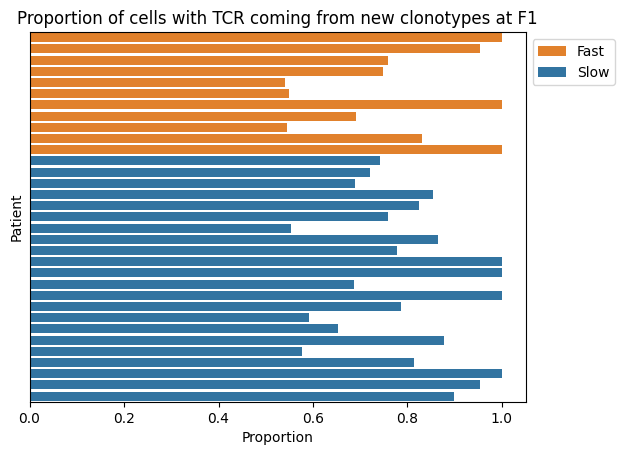

In [31]:
custom_palette = ['tab:orange','tab:blue']
sns.set_palette(custom_palette)
sns.barplot(data=temp,x='Proportion',y=temp.index,hue='Progression')
plt.yticks([])
plt.title('Proportion of cells with TCR coming from new clonotypes at F1')
plt.ylabel('Patient')
plt.legend(bbox_to_anchor=(1,1))

In [32]:
temp = pd.DataFrame(pd.DataFrame(pd.Series([i.split('_')[1] for i in adata[(
    adata.obs['timepoint'] == 'F2') & (
    adata.obs['clonotype_patient'].isin(new_clones_f2))].obs['clonotype_patient']])).value_counts(
    
    ) / pd.DataFrame(pd.Series([i.split('_')[1] for i in adata[(
    adata.obs['timepoint'] == 'F2') & (
    adata.obs['clonotype_patient'].isin(clonotypes_f2))].obs['clonotype_patient']])).value_counts()).dropna()
temp.columns = ['Proportion']
temp = temp.reset_index()
temp.index = temp[0]
del temp[0]
temp['Progression'] = temp.index.map(progression_dict)
temp = temp.sort_values('Progression')

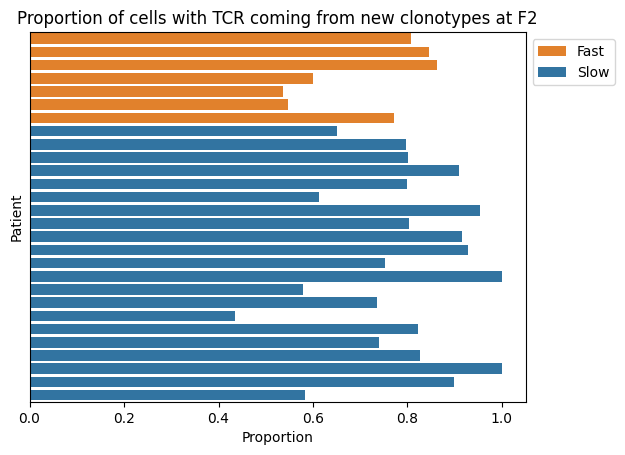

In [33]:
custom_palette = ['tab:orange','tab:blue']
sns.set_palette(custom_palette)
sns.barplot(data=temp,x='Proportion',y=temp.index,hue='Progression')
plt.yticks([])
plt.title('Proportion of cells with TCR coming from new clonotypes at F2')
plt.ylabel('Patient')
plt.legend(bbox_to_anchor=(1,1))